<img src="jupyterN.png">

## Формулы

### Уравнения Лотки-Вольтерра
$$\large  x(t+\frac{\tau}{2}) = \frac{6}{11} \cdot (\frac{\tau}{2}(a(t)x(t) -x(t)y(t)) + \frac{1}{3} x(t-\tau) - 1.5x(t -\frac{1}{2}\tau) + 3x(t))$$

$$\large  y(t+\frac{\tau}{2}) =\frac{6}{11}\cdot (\frac{\tau}{2}( bx(t)y(t) -cy(t)) + \frac{1}{3} x(t-\tau) - 1.5x(t -\frac{1}{2}\tau) + 3x(t))$$

### Уравнения миграции
#### СЛАУ

$$\Large \dot x_i = \nu_x \sum_{j\in сопредельные} (x_j - x_i)$$

$$\Large \dot x_i = \nu_x {x_{j_1}} +\nu_x {x_{j_2}} +...+ \nu_x {x_{j_k}}  - \nu_xkx_i$$

Где k - число сопряжённых клеток.

$$\Large \frac{x_i(t+\tau) - x_i(t+\frac{\tau}{2})}{\frac{\tau}{2}} = \nu_x {x_{j_1}(t+\frac{\tau}{2})} +\nu_x {x_{j_2}(t+\frac{\tau}{2})} +...+ \nu_x {x_{j_k}(t+\frac{\tau}{2})}  - \nu_xkx_i(t+\frac{\tau}{2})$$

$$\Large x_i(t+\tau) = \frac{\tau}{2}\nu_x {x_{j_1}(t+\frac{\tau}{2})} +\frac{\tau}{2}\nu_x {x_{j_2}(t+\frac{\tau}{2})} +...+ \frac{\tau}{2}\nu_x {x_{j_k}(t+\frac{\tau}{2})}  - \frac{\tau}{2}\nu_xkx_i(t+\frac{\tau}{2}) + x_i(t+\frac{\tau}{2})$$

$$\Large x_i(t+\tau) = \frac{\tau}{2}\nu_x {x_{j_1}(t+\frac{\tau}{2})} +\frac{\tau}{2}\nu_x {x_{j_2}(t+\frac{\tau}{2})} +...+ \frac{\tau}{2}\nu_x {x_{j_k}(t+\frac{\tau}{2})}  + (1 - \frac{\tau}{2}\nu_xk)x_i(t+\frac{\tau}{2})$$
Для всех ячеек получим

$$\Large x(t+\tau) = Ax(t+\frac{\tau}{2})$$

Аналогично и для $y$

## Моделирование

### Рассчёт матрицы смежных клеток

In [ ]:
import math as mt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import random

In [ ]:
# Матрица смежных клеток
class JupyterMatrix:
  def __init__(self):
    self.elements_count = 44
    self.array = np.zeros([self.elements_count, self.elements_count], dtype = np.int8)
    self.fill_neighbors()
    self.set_borders()
    self.set_diagonals()


  def fill_neighbors(self):
    count = 0
    for i in range(0, self.elements_count):
      if (count - 1 >= 0):
        self.array[i][count - 1] = 1
      if (count - 7 >= 0):
        self.array[i][count - 7 ] = 1
      if (count - 6 >= 0):
        self.array[i][count - 6 ] = 1
      if (count + 1 < self.elements_count):
        self.array[i][count + 1] = 1
      if (count + 7 < self.elements_count):
        self.array[i][count + 7 ] = 1
      if (count + 6 < self.elements_count):
        self.array[i][count + 6 ] = 1
      count += 1

  def set_neighborns(self, idx, neighborns):
    i = idx - 1
    self.array[i] = np.zeros([self.elements_count], dtype = np.int8)
    for j in neighborns:
      self.array[i][j-1] = 1

  def set_borders(self):
    self.set_neighborns(1, [2, 5, 6])
    self.set_neighborns(2, [1, 6, 7, 3])
    self.set_neighborns(3, [2, 7, 8, 4])
    self.set_neighborns(4, [3, 8, 9])
    self.set_neighborns(5, [1, 6, 12, 11])
    self.set_neighborns(6, [1, 2, 7, 13, 12, 5])
    self.set_neighborns(7, [2, 3, 8, 14, 13, 6])
    self.set_neighborns(8, [3, 4, 9, 15, 14, 7])
    self.set_neighborns(9, [4, 10, 16, 15, 8])
    self.set_neighborns(10, [9, 17, 16])
    self.set_neighborns(11, [5, 12, 18])
    self.set_neighborns(17, [10, 16, 24, 23])
    self.set_neighborns(18, [11, 12, 19, 25])
    self.set_neighborns(24, [17, 23, 31, 30])
    self.set_neighborns(25, [18, 19, 26, 32])
    self.set_neighborns(31, [24, 30, 38, 37])
    self.set_neighborns(32, [25, 26, 33, 39])
    self.set_neighborns(38, [31, 37, 44])
    self.set_neighborns(39, [32, 33, 40])
    self.set_neighborns(40, [33, 34, 41, 39])
    self.set_neighborns(41, [34, 35, 42, 40])
    self.set_neighborns(42, [35, 36, 43, 41])
    self.set_neighborns(43, [36, 37, 44, 42])
    self.set_neighborns(44, [37, 38, 43])

  def set_diagonals(self):
    for i in range(0, self.elements_count):
      not_zero_el = 0
      for j in range(0, self.elements_count):
        if (self.array[i][j] == 1):
          not_zero_el += 1
      self.array[i][i] = -not_zero_el
  def change_for_diagonal(self, num):
    for i in range(0, self.elements_count):
      self.array[i][i] += num
  def multiple_matrix(self, num):
    self.array = self.array * num
  def get_matrix(self):
    return self.array

### Класс модели

In [ ]:
class Modeling():
  def __init__(self, initial_x_data, initial_y_data):
    self.w = 1
    self.b = 0.9
    self.c = 4
    self.tau = 0.001
    self.g_0 = 5
    self.a = lambda t: self.g_0 * (1 + mt.sin(self.w*t))
    self.start_num = 3
    self.iterations = 10000
    self.split_iterations = self.iterations * 2 + 1

    self.a_0 = -1/3 # a_{-2}
    self.a_1 = 1.5  # a_{-1}
    self.a_2 = -3 # a_0
    self.a_3 = 11/6 # a_1

    self.v_x = 5.4
    self.v_y = 5.4

    self.time = np.linspace(0, (self.tau/2) * self.split_iterations, self.split_iterations)
    self.vector_size = 44
    self.x = np.zeros([self.vector_size, self.split_iterations], dtype='d')
    self.y = np.zeros([self.vector_size, self.split_iterations], dtype='d')
    self.migration_x_matrix = self.create_migration_matrix(self.v_x)
    self.migration_y_matrix = self.create_migration_matrix(self.v_y)
    self.fill_arrays(initial_x_data, initial_y_data)

  def create_migration_matrix(self, v):
    matrix_object = JupyterMatrix()
    matrix_object.multiple_matrix((self.tau/2) * v)
    matrix_object.change_for_diagonal(1)
    return matrix_object.get_matrix()

  def fill_arrays(self, initial_x_data, initial_y_data):
    for i in range(0, self.vector_size):
      for j in range(0, self.start_num):
        self.x[i][j] = initial_x_data[i][j]
        self.y[i][j] = initial_y_data[i][j]

  def fill_arrays_random(self):
    for i in range(0, self.vector_size):
      for j in range(0, self.start_num):
        self.x[i][0:self.start_num] = random.uniform(7, 15)
        self.y[i][0:self.start_num] = random.uniform(3.2, 7.8)

  def get_arrays(self, cell_number):
    x_tau = [self.x[cell_number-1][i] for i in range(0, self.split_iterations, 2)]
    y_tau = [self.y[cell_number-1][i] for i in range(0, self.split_iterations, 2)]
    t_tau = [self.time[i] for i in range(0, self.split_iterations, 2)]
    return x_tau, y_tau, t_tau

  def start(self):
    for iter in range(self.start_num, self.split_iterations, 2):
      self.lotka_volterra_step(iter)
      self.migration_step(iter)

  def lotka_volterra_step(self, iter):
    for hex_num in range(0, self.vector_size):
        self.lotka_volterra(self.x[hex_num], self.y[hex_num], iter)

  def migration_step(self, iter):
    x_mig = self.migration(self.migration_x_matrix, self.x[:,iter])
    y_mig = self.migration(self.migration_y_matrix, self.y[:,iter])
    self.x[:,iter + 1] = x_mig
    self.y[:,iter + 1] = y_mig

  def lotka_volterra(self, x, y, i):
    x[i] = (self.tau/2 *(self.a(self.time[i])*x[i-1] - x[i-1]*y[i-1]) - self.a_0*x[i-3] - self.a_1*x[i-2] - self.a_2*x[i-1]) / self.a_3
    y[i] = (self.tau/2 *(self.b*x[i-1]*y[i-1] - self.c*y[i-1]) - self.a_0*y[i-3] - self.a_1*y[i-2] - self.a_2*y[i-1]) / self.a_3

  def migration(self, migration_matrix, arr):
    result = np.zeros([self.vector_size], dtype='d')
    for i in range(0, self.vector_size):
      for j in range(0, self.vector_size):
        result[i] += (float)(migration_matrix[i][j] * arr[j])
    return result

  def set_cell_zero(self, cell_number):
    self.x[cell_number - 1] = np.zeros((self.split_iterations))
    self.y[cell_number - 1] = np.zeros((self.split_iterations))

### Начальные данные

Для всех ячеек выбираются по три случайных значения для $x$ из отрезка [7, 15] и по три значения для $y$ из отрезка [3.2, 7.8].

Также, несколько клеток задаётся изначально пустыми.

In [ ]:
x_min, x_max = 7, 15
y_min, y_max = 3.2, 7.8
x_step = 0.5
y_step = 0.5
initial_x_data = np.zeros([44,3], dtype='d')
initial_y_data = np.zeros([44,3], dtype='d')
for i in range(0, 44):
  for j in range(0, 3):
    if j == 0:
      initial_x_data[i][j] = random.uniform(x_min, x_max)
      initial_y_data[i][j] = random.uniform(y_min, y_max)
    else:
      initial_x_data[i][j] = initial_x_data[i][j - 1] + x_step
      initial_y_data[i][j] = initial_y_data[i][j - 1] + y_step

# Ячейки, которые будут изначально пустые
zero_cells = [5, 10, 12, 16, 33, 34, 18]

### Моделирование

In [ ]:
model = Modeling(initial_x_data, initial_y_data)
for cell in zero_cells:
  model.set_cell_zero(cell)
model.start()

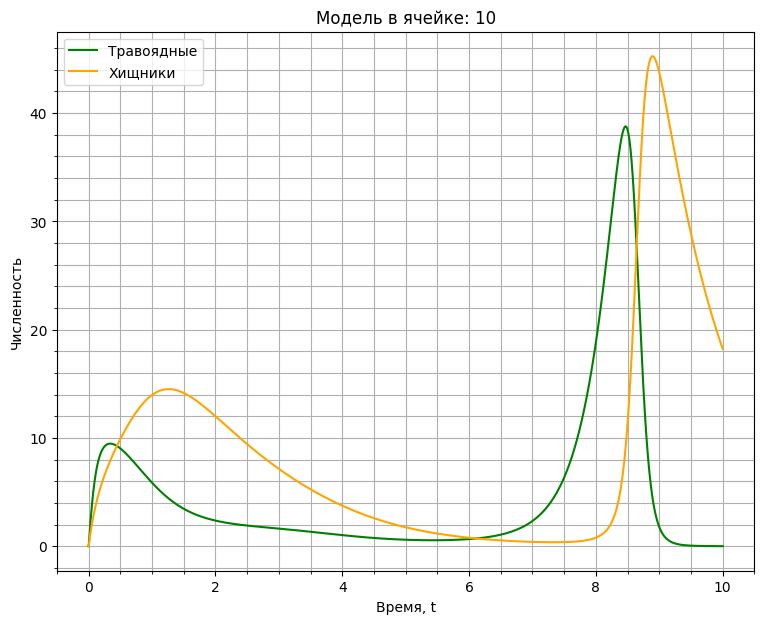

In [ ]:
cell_number = 10

x, y, t_arr = model.get_arrays(cell_number)
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
# ax.set_xlim((0, 0.1))
ax.grid(True, which='both')
ax.minorticks_on()


ax.plot(t_arr,x, color="green", label="Травоядные")
ax.plot(t_arr,y, color ="orange", label="Хищники")

ax.legend()
ax.set_xlabel("Время, t")
ax.set_ylabel("Численность")
ax.set_title(f"Модель в ячейке: {cell_number}")
plt.savefig('scheme.png')

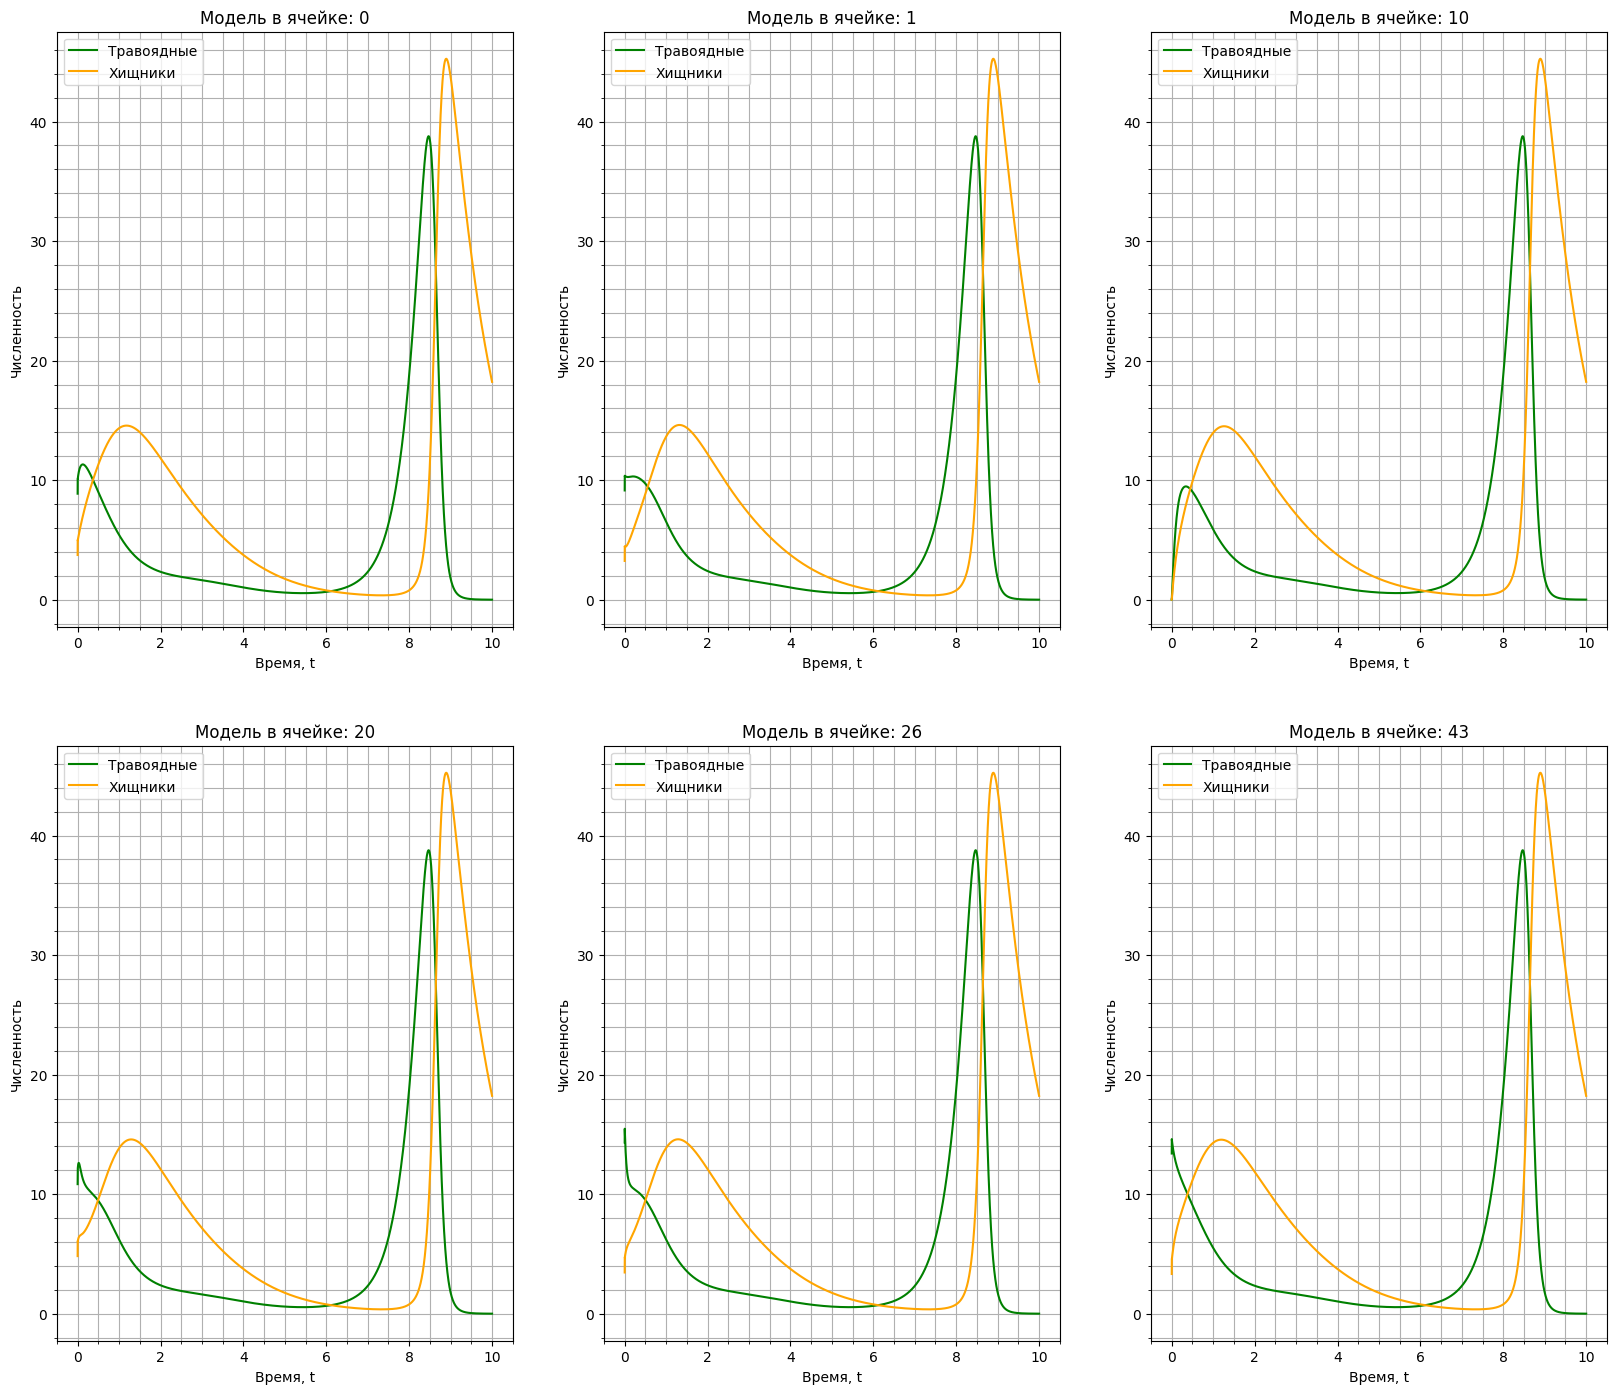

In [ ]:
fig = plt.figure(figsize=(20, 17))
cells = [[0, 1, 10],[20, 26, 43]]
h_num, v_num = 2, 3
ax = fig.subplots(h_num, v_num)
for i in range(0, h_num):
  for j in range(0, v_num):
    cell_number = cells[i][j]
    x, y, t_arr = model.get_arrays(cell_number)
    ax[i][j].grid(True, which='both')
    ax[i][j].minorticks_on()
    ax[i][j].plot(t_arr,x, color="green", label="Травоядные")
    ax[i][j].plot(t_arr,y, color ="orange", label="Хищники")
    ax[i][j].legend()
    ax[i][j].set_xlabel("Время, t")
    ax[i][j].set_ylabel("Численность")
    ax[i][j].set_title(f"Модель в ячейке: {cell_number}")
# plt.savefig('scheme.png')

## Обусловленность СЛАУ

$$ \mu(A) = \|A^{-1}\|\ \|A\|  $$

In [ ]:
x_matrix = model.migration_x_matrix
y_matrix = model.migration_y_matrix
print(f"Число обусловленности матрицы x = {np.linalg.cond(x_matrix)}")
print(f"Число обусловленности матрицы y = {np.linalg.cond(y_matrix)}")

x_matrix_dframe = pd.DataFrame(data=x_matrix[:,:],index=range(1, 45), columns=range(1, 45))
x_matrix_dframe.to_excel("output_matrix.xlsx")

Число обусловленности матрицы x = 1.023740744014709
Число обусловленности матрицы y = 1.023740744014709


**Матрица СЛАУ**

Для $x$

In [ ]:
x_matrix_dframe

,1,2,3,4,5,6,7,8,9,10,...,35,36,37,38,39,40,41,42,43,44
1,0.9919,0.0027,0.0000,0.0000,0.0027,0.0027,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.0027,0.9892,0.0027,0.0000,0.0000,0.0027,0.0027,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.0000,0.0027,0.9892,0.0027,0.0000,0.0000,0.0027,0.0027,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.0000,0.0000,0.0027,0.9919,0.0000,0.0000,0.0000,0.0027,0.0027,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.0027,0.0000,0.0000,0.0000,0.9892,0.0027,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.0027,0.0027,0.0000,0.0000,0.0027,0.9838,0.0027,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.0000,0.0027,0.0027,0.0000,0.0000,0.0027,0.9838,0.0027,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.0000,0.0000,0.0027,0.0027,0.0000,0.0000,0.0027,0.9838,0.0027,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,0.0000,0.0000,0.0000,0.0027,0.0000,0.0000,0.0000,0.0027,0.9865,0.0027,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
10,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0027,0.9919,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Вывод о обусловленности СЛАУ
Число обусловленности $≈$ 1. СЛАУ обусловлена хорошо.

## Практическое исследование обусловленности

Все начальные значения для $x$ и для $y$ увеличим на 0.5

In [ ]:
initial_x_data += 0.5
initial_y_data += 0.5
model_changed = Modeling(initial_x_data, initial_y_data)
for cell in zero_cells:
  model_changed.set_cell_zero(cell)
model_changed.start()

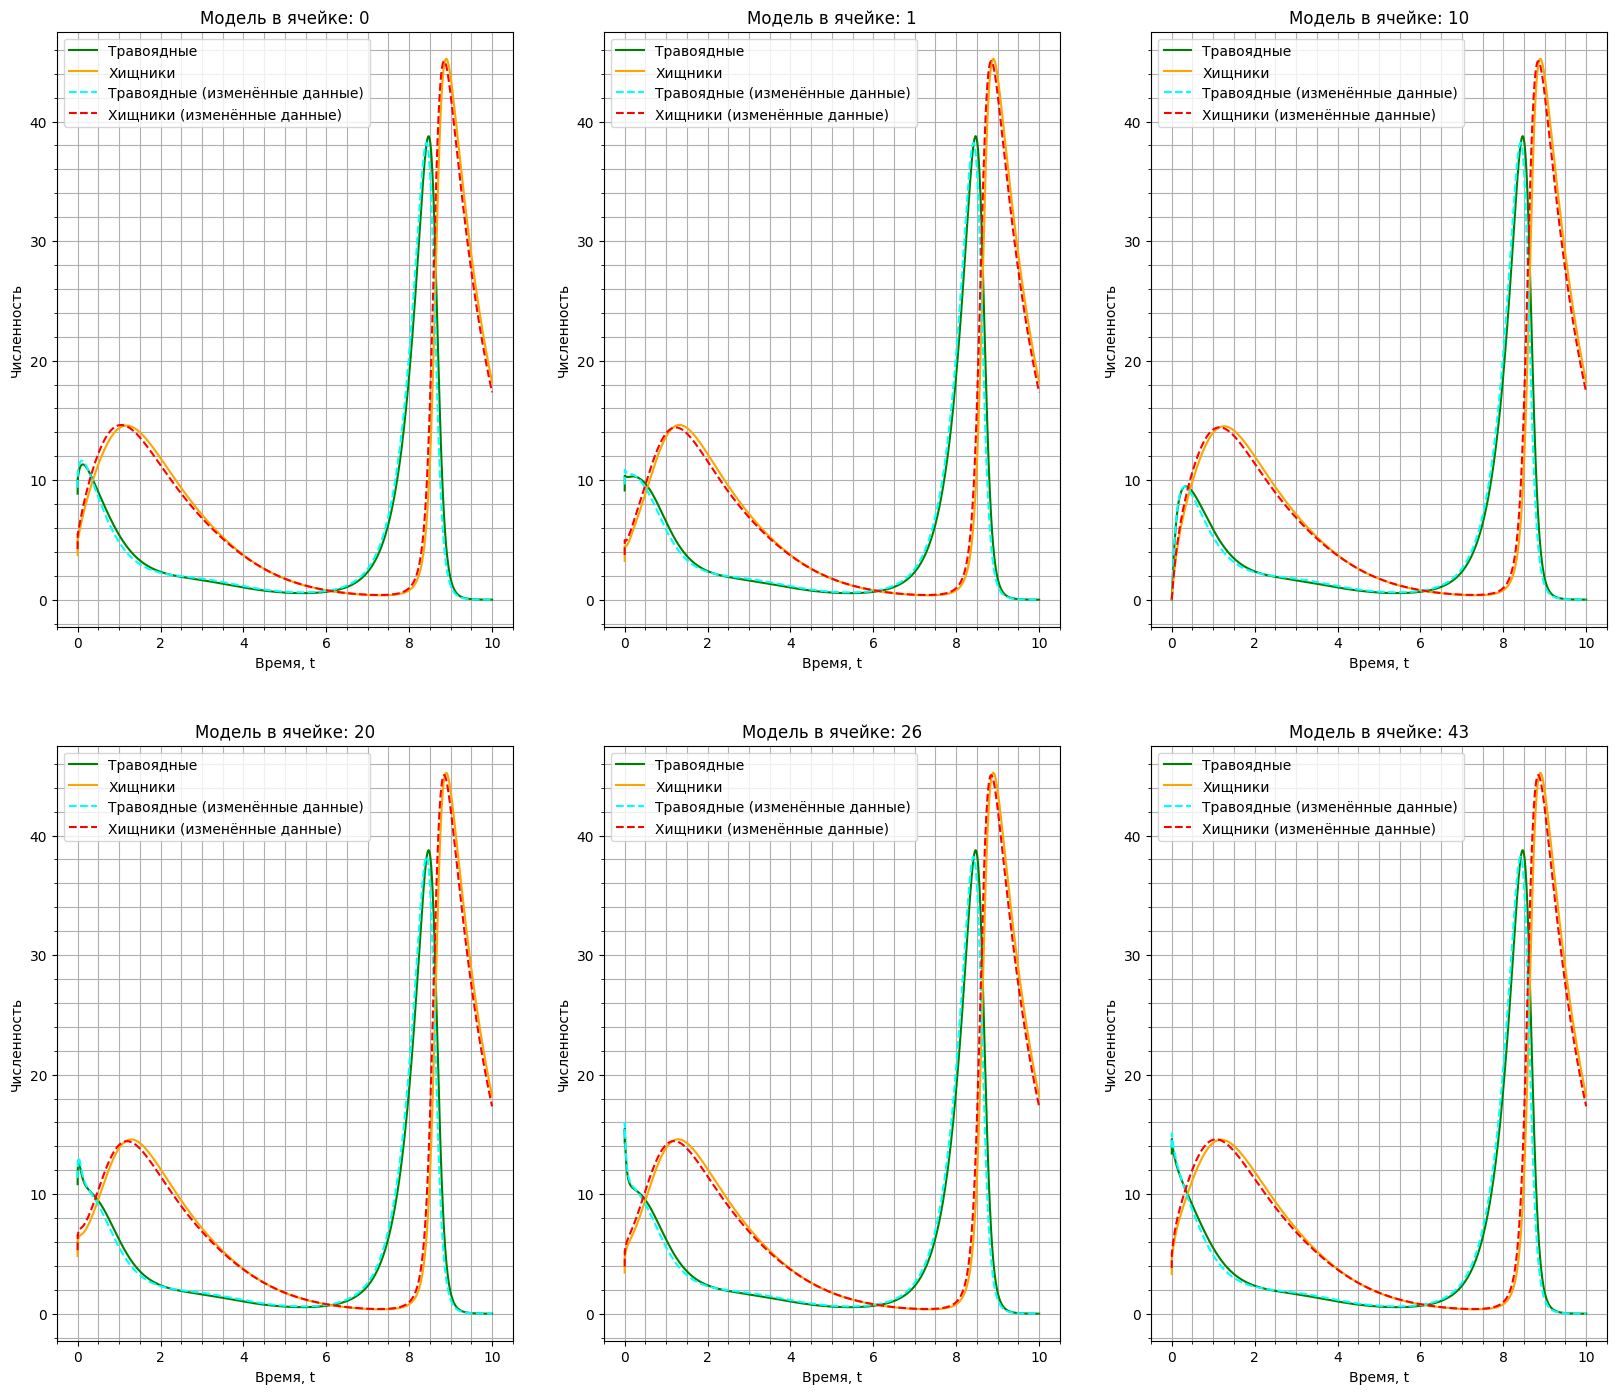

In [ ]:
fig = plt.figure(figsize=(20, 17))
cells = [[0, 1, 10],[20, 26, 43]]
h_num, v_num = 2, 3
ax = fig.subplots(h_num, v_num)
for i in range(0, h_num):
  for j in range(0, v_num):
    cell_number = cells[i][j]
    x, y, t_arr = model.get_arrays(cell_number)
    x_n, y_n, _ = model_changed.get_arrays(cell_number)
    ax[i][j].grid(True, which='both')
    ax[i][j].minorticks_on()
    ax[i][j].plot(t_arr,x, color="green", label="Травоядные")
    ax[i][j].plot(t_arr,y, color ="orange", label="Хищники")
    ax[i][j].plot(t_arr,x_n, color="cyan", ls ='--', label="Травоядные (изменённые данные)")
    ax[i][j].plot(t_arr,y_n, color ="red", ls = '--', label="Хищники (изменённые данные)")
    ax[i][j].legend()
    ax[i][j].set_xlabel("Время, t")
    ax[i][j].set_ylabel("Численность")
    ax[i][j].set_title(f"Модель в ячейке: {cell_number}")

### Выводы о практической обусловленности

Видно, что при малом изменении начальных данных, результаты меняются слабо. Обусловленность хорошая